### Introduction to Manifold Diffusion Geometry

This notebook follows the computation in [Manifold Diffusion Geometry: Curvature, Tangent Spaces, and Dimension](https://arxiv.org/abs/2411.04100). The aim is to take a point cloud and compute familiar manifold geometry: tangent spaces, dimension, and scalar curvature.

We assume the data behave like points sampled from a low-dimensional manifold embedded in Euclidean space. We use diffusion geometry to estimate the intrinsic geometry from the heat flow on the data. The heat flow gives a Laplacian, and the Laplacian gives the carré du champ

$$
\Gamma(f,h)=g(\nabla f,\nabla h).
$$

Once $\Gamma$ is known, Riemannian geometry becomes linear algebra.

*The plots in this notebook are interactive*


In [6]:
from pathlib import Path
import site
import sys

import os

import numpy as np

from preprocess_file import compute_contrast_norm, sample_from_data_set
import numpy as np
from opt_einsum import contract
import plotly.io as pio
from TDA.optical_flow_torus.preprocess_file import preprocess_file, get_high_contrast_patches, normalize_patches, knn_density_threshold


In [ ]:
folderpath = "/home/martincc/Downloads/MPI-Sintel-complete/training/flow/"

NUM_PATCHES = 385
PATCH_SIZE = 3

subfolders = sorted(
    entry.path for entry in os.scandir(folderpath) if entry.is_dir()
)

allpatches_list = []
for tempdir in subfolders:
    # Get all .flo files in this subdirectory and process them.
    filelist = sorted(
        f for f in os.listdir(tempdir) if f.endswith(".flo")
    )
    numfiles = len(filelist)
    folderpatches = np.zeros((NUM_PATCHES * numfiles, 2 * PATCH_SIZE ** 2 + 1))
    for i, fname in enumerate(filelist):
        filepath = os.path.join(tempdir, fname)

        patches = sample_from_data_set(filepath, NUM_PATCHES, PATCH_SIZE, rng=None)
        # Step 2: compute contrast norm.
        patches = compute_contrast_norm(patches)

        folderpatches[i * NUM_PATCHES:(i + 1) * NUM_PATCHES, :] = patches
    if numfiles > 0:
        allpatches_list.append(folderpatches)

result = np.vstack(allpatches_list)
# Step 3: keep only high-contrast patches.
hc_patches = get_high_contrast_patches(patches)
# Step 4: random downsample (skipped, as in the original).
# Step 5: normalize.
hc_patches = normalize_patches(hc_patches)
# Step 6: drop the contrast-norm column, then filter by density.
n = hc_patches.shape[1]
hc_patches = hc_patches[:, :n - 1]
result =  knn_density_threshold(hc_patches, 300, 20)

print()
print("Processed patches shape:", result.shape)

/home/martincc/Documents/AIDOS/diffusion_geometry/DiffusionGeometryFribourg/TDA/optical_flow_torus/preprocess_file.py:211: UserWarning: 20 percent of 77 points is not an integer. Taking the 15 densest points
  warnings.warn(


ValueError: could not broadcast input array from shape (15,18) into shape (385,30)

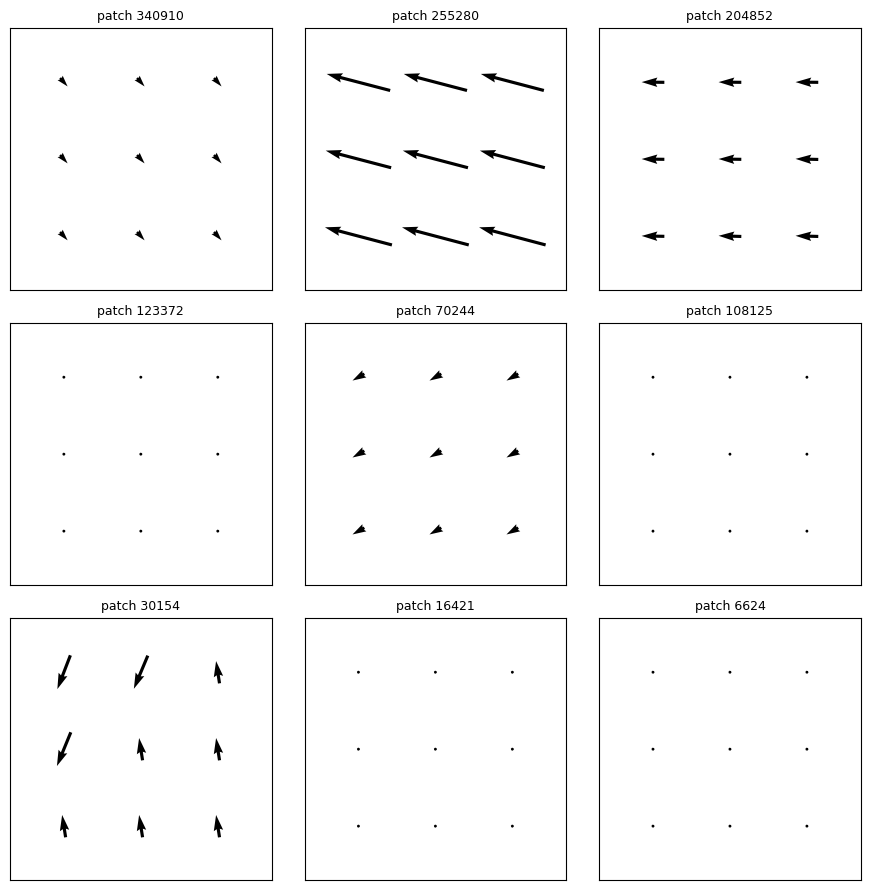

[340910, 255280, 204852, 123372, 70244, 108125, 30154, 16421, 6624]

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_flow_patches(data, k=6, indices=None, colmajor=True, seed=0, show_mean=False):
    """
    data : (n, 18) or (n, 20) array of optical-flow patches.
           cols 0:9 = u1..u9, 9:18 = v1..v9, [18:20] = mean (ubar, vbar) if present.
    k    : number of patches to sample (ignored if `indices` given)
    """
    arr = data.detach().cpu().numpy() if hasattr(data, "detach") else np.asarray(data, float)
    n, d = arr.shape

    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(n, size=min(k, n), replace=False)
    indices = list(indices)
    k = len(indices)

    order = "F" if colmajor else "C"   # paper uses column-major
    def unpack(row):
        u = row[0:9].reshape(3, 3, order=order)
        v = row[9:18].reshape(3, 3, order=order)
        mean = row[18:20] if d >= 20 else np.zeros(2)
        return u, v, mean

    # shared scale so arrow lengths are comparable across patches
    mags = [np.hypot(*unpack(arr[i])[:2]).max() for i in indices]
    scale = max(np.max(mags), 1e-9) / 0.9   # longest arrow ~0.9 grid units

    # grid: column -> x, row -> y with row 0 on top so +v points up
    gx, gy = np.meshgrid([0, 1, 2], [2, 1, 0])

    cols = min(k, 3)
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows), squeeze=False)
    axes = axes.ravel()

    for ax, idx in zip(axes, indices):
        U, V, mean = unpack(arr[idx])
        ax.quiver(gx, gy, U, V, angles="xy", scale_units="xy",
                  scale=scale, pivot="mid", width=0.012, color="black")
        ax.set_xlim(-0.7, 2.7); ax.set_ylim(-0.7, 2.7)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        title = f"patch {idx}"
        if show_mean and d >= 20:
            title += f"\nmean=({mean[0]:.2f}, {mean[1]:.2f})"
        ax.set_title(title, fontsize=9)

    for ax in axes[k:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return indices

# usage
plot_flow_patches(result, k=9)                       # random 6
# plot_flow_patches(my_tensor, indices=[0, 12, 57])     # specific patches